## Neural Network Training(신경망 학습)

신경망 학습은 정답 데이터와 비교하면서 가중치와 편향을 조금씩 조정해 더 좋은 예측을 만들도록 하는 과정입니다. 이때 모델이 현재 얼마나 잘못 예측하고 있는지를 수치로 보여주는 기준이 필요하며, 그 기준이 바로 손실함수입니다.


## 손실함수(Loss Function)

손실함수는 신경망의 예측값과 실제 정답 사이의 차이를 하나의 숫자로 나타내는 함수입니다. 예측이 정답에 가까우면 손실값은 작아지고, 예측이 많이 벗어나면 손실값은 커집니다.

신경망 학습의 목적은 이 손실값을 가능한 한 줄이는 것입니다. 학습 과정에서 모델은 손실함수를 기준으로 어떤 방향으로 가중치를 바꿔야 하는지 판단하고, 이를 반복하면서 더 나은 예측을 하게 됩니다.

즉, 손실함수는 모델의 성능을 숫자로 확인하는 도구이면서 동시에 학습의 방향을 정해 주는 기준이라고 볼 수 있습니다.


### 오차제곱합(Sum of Squares for Error)

오차제곱합은 각 출력값의 예측과 정답 사이의 차이를 제곱해서 모두 더한 손실함수입니다. 예측값과 정답값의 차이가 클수록 손실이 더 크게 반영되며, 큰 오차에 민감하게 반응하는 특징이 있습니다.

$$
E = \frac{1}{2} \sum_k (y_k - t_k)^2
$$

여기서 $`y_k`$는 신경망의 출력값이고, $`t_k`$는 정답 레이블을 의미합니다. 앞의 $`\frac{1}{2}`$는 미분할 때 계산을 단순하게 만들기 위해 붙이는 경우가 많습니다.


### 교차 엔트로피 오차(Cross Entropy Error)

다중 분류에서 교차 엔트로피 오차는 정답 레이블에 해당하는 확률을 중심으로 손실을 계산하는 방법입니다. 정답인 클래스에 높은 확률을 줄수록 손실은 작아지고, 정답 클래스의 확률이 낮을수록 손실은 크게 증가합니다.

$$
E = - \sum_k t_k \log y_k
$$

이 식은 정답 레이블이 one-hot encoding으로 표현된 다중 분류를 가정합니다. 따라서 실제로는 정답인 위치의 값만 손실 계산에 반영된다고 볼 수 있습니다.

오차제곱합은 예측값과 정답값의 거리 차이를 보는 방식이고, 교차 엔트로피 오차는 정답 클래스에 얼마나 높은 확률을 주었는지에 더 민감하게 반응합니다.


### 손실함수와 가중치 업데이트

손실함수는 단순히 현재 예측이 얼마나 틀렸는지 보여주는 점수표가 아니라, 가중치를 어느 방향으로 얼마나 바꿔야 하는지를 알려주는 학습 신호를 만듭니다. 신경망은 먼저 현재 가중치로 예측값을 만들고, 손실함수로 정답과의 차이를 계산한 뒤, 그 손실이 줄어드는 방향으로 가중치를 조금씩 수정합니다.

이때 핵심은 손실함수가 미분 가능한 형태로 정의되어 있다는 점입니다. 손실을 출력값과 가중치에 대해 미분하면, 어떤 출력이 너무 크고 어떤 출력이 너무 작은지, 그리고 그 오차를 줄이려면 가중치를 증가시켜야 하는지 감소시켜야 하는지를 알 수 있습니다.

$$
w \leftarrow w - \eta \frac{\partial E}{\partial w}
$$

여기서 $`\eta`$는 학습률(learning rate)이고, $`\frac{\partial E}{\partial w}`$는 손실함수로부터 얻은 기울기입니다. 기울기가 크면 가중치를 더 크게 수정하고, 기울기가 작으면 조금만 수정합니다. 즉, 손실함수는 학습의 목표를 숫자로 정의할 뿐 아니라, 그 목표를 향해 이동하는 방법까지 함께 제공합니다.

![Loss guides weight updates](img/loss_guides_weight_update.svg)


오차제곱합과 교차 엔트로피 오차는 모두 가중치 업데이트에 필요한 신호를 만들지만, 그 신호의 성격은 다릅니다.

오차제곱합에서는 예측값과 정답의 차이 자체가 바로 출력층의 수정 신호가 됩니다.

$$
\frac{\partial E}{\partial y_k} = y_k - t_k
$$

따라서 예측이 정답보다 크면 그 출력을 줄이는 방향으로, 예측이 정답보다 작으면 그 출력을 키우는 방향으로 학습이 진행됩니다. 차이가 클수록 더 큰 수정 신호가 생기므로, 모델은 큰 오차를 먼저 줄이도록 움직입니다.

교차 엔트로피 오차에서는 정답 클래스에 얼마나 낮은 확률을 주었는지가 더 직접적으로 반영됩니다.

$$
\frac{\partial E}{\partial y_k} = - \frac{t_k}{y_k}
$$

다중 분류에서 정답 레이블이 one-hot encoding이라면 정답 위치만 손실에 직접 기여합니다. 그래서 정답 클래스의 확률이 매우 낮을 때는 더 강한 수정 신호가 생기고, 정답 클래스의 확률이 높아질수록 손실과 수정 신호가 빠르게 줄어듭니다. 이 성질 때문에 교차 엔트로피 오차는 분류 문제에서 학습 방향을 더 분명하게 잡아 주는 경우가 많습니다.


### 미니배치 학습(Mini-batch Learning)

지금까지의 손실함수는 한 개의 데이터에 대해 손실을 계산하는 형태로 설명할 수 있지만, 실제 학습에서는 보통 여러 데이터를 한 번에 묶어서 손실을 계산합니다. 전체 훈련 데이터를 한 번에 모두 사용하면 계산량이 매우 커지고 메모리 부담도 커지기 때문에, 데이터의 일부를 작은 묶음으로 나누어 사용하는 방식이 일반적입니다. 이 작은 묶음을 미니배치(mini-batch)라고 합니다.

미니배치 학습에서는 배치 안에 포함된 여러 샘플의 손실을 합하거나 평균내어 한 번의 업데이트에 사용합니다. 이렇게 하면 한 개의 데이터만 사용할 때보다 손실과 기울기가 덜 불안정하고, 전체 데이터를 한 번에 사용할 때보다 훨씬 빠르게 반복 학습을 진행할 수 있습니다.

다중 분류에서 교차 엔트로피 오차를 미니배치에 대해 평균내면 다음과 같이 쓸 수 있습니다.

$$
E = - \frac{1}{N} \sum_{n=1}^{N} \sum_k t_{nk} \log y_{nk}
$$

여기서 $`N`$은 미니배치에 포함된 데이터 개수이고, $`t_{nk}`$는 $`n`$번째 데이터의 정답 레이블, $`y_{nk}`$는 그 데이터에 대한 신경망의 출력값입니다. 즉, 미니배치 학습은 여러 데이터의 손실을 함께 반영해 한 번에 가중치를 업데이트하는 방법이라고 볼 수 있습니다.

정리하면, 미니배치 학습은 계산 효율을 높이고, 메모리 부담을 줄이며, 손실과 기울기를 조금 더 안정적으로 만들어 실제 신경망 학습에서 매우 널리 사용됩니다.


In [1]:
from pathlib import Path

repo_dir = Path("../deep-learning-from-scratch")

if not repo_dir.exists():
    print("should clone the repository first")
else:
    print("repository exists")


repository exists


In [2]:
import sys
import numpy as np

if str(repo_dir.resolve()) not in sys.path:
    sys.path.append(str(repo_dir.resolve()))
    

from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(
    normalize=True,
    # flatten=True,
    one_hot_label=True,
)

print(x_train.shape)
print(t_train.shape)

(60000, 784)
(60000, 10)


In [3]:
# 10개의 데이터를 무작위로 선택하여 배치(batch)를 만듭니다.
train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]
print(x_batch.shape)
print(t_batch.shape)


(10, 784)
(10, 10)


In [4]:
def cross_entropy_error(y : np.ndarray, t : np.ndarray):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    # one-hot encoding
    return -np.sum(t * np.log(y + 1e-7)) / batch_size
    # class index
    # return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

### 수치 미분(Numerical Differentiation)

수치 미분은 아주 작은 변화량 `h`를 이용해 함수의 기울기를 근사하는 방법입니다. 해석적으로 미분 공식을 바로 구하기 어려울 때, 함수값의 변화를 직접 비교해 기울기를 추정할 수 있습니다.

$$
\frac{df(x)}{dx} \approx \frac{f(x+h) - f(x-h)}{2h}
$$

앞차분보다 중앙차분이 더 안정적이어서 보통 위 공식을 사용합니다. 실제 신경망 학습에서는 계산 비용 때문에 수치 미분으로 모든 가중치의 기울기를 구하지는 않지만, 기울기와 경사하강법의 의미를 이해하는 데에는 매우 좋은 출발점입니다.


In [5]:
def numerical_diff(f, x):
    h = 1e-4
    return (f(x + h) - f(x - h)) / (2 * h)


def function_1(x):
    return 0.01 * x**2 + 0.1 * x


print("f'(5)  ~=", numerical_diff(function_1, 5.0))
print("f'(10) ~=", numerical_diff(function_1, 10.0))


f'(5)  ~= 0.1999999999990898
f'(10) ~= 0.2999999999986347


### 편미분(Partial Derivative)과 기울기(Gradient)

변수가 여러 개인 함수에서는 한 변수만 바꾸고 나머지는 고정한 상태에서 미분한 값을 편미분이라고 합니다. 예를 들어 `f(x_0, x_1)`에서 `x_0`에 대한 편미분은 `x_1`을 고정한 채 `x_0`만 조금 바꾸며 본 변화율입니다.

각 변수에 대한 편미분을 한데 모으면 기울기(gradient) 벡터가 됩니다.

$$
\nabla f(x) = \left( \frac{\partial f}{\partial x_0}, \frac{\partial f}{\partial x_1}, \cdots \right)
$$

기울기는 함수값이 가장 가파르게 증가하는 방향을 가리킵니다. 따라서 손실을 줄이고 싶다면 기울기의 반대 방향, 즉 $`-\nabla f`$ 방향으로 이동하면 됩니다.


In [6]:
import matplotlib.pyplot as plt


def function_2(x):
    return x[0]**2 + x[1]**2


def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x, dtype=float)

    for idx in range(x.size):
        tmp_val = x[idx]

        x[idx] = tmp_val + h
        fxh1 = f(x)

        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2 * h)
        x[idx] = tmp_val

    return grad


point = np.array([3.0, 4.0])

partial_x0 = numerical_diff(lambda x0: function_2(np.array([x0, point[1]])), point[0])
partial_x1 = numerical_diff(lambda x1: function_2(np.array([point[0], x1])), point[1])
grad = numerical_gradient(function_2, point.copy())

print("df/dx0 at (3, 4) =", partial_x0)
print("df/dx1 at (3, 4) =", partial_x1)
print("gradient at (3, 4) =", grad)


df/dx0 at (3, 4) = 6.00000000000378
df/dx1 at (3, 4) = 7.999999999999119
gradient at (3, 4) = [6. 8.]


### 기울기 벡터 필드와 가장 가파른 하강 방향

기울기를 여러 점에서 계산해 화살표로 그리면 함수 표면 위에서 어느 방향이 가장 빠르게 증가하거나 감소하는지 시각적으로 볼 수 있습니다. 아래 그림에서는 $`-\nabla f`$를 그려서 각 점에서 함수값을 가장 빠르게 줄이는 방향을 표시합니다.


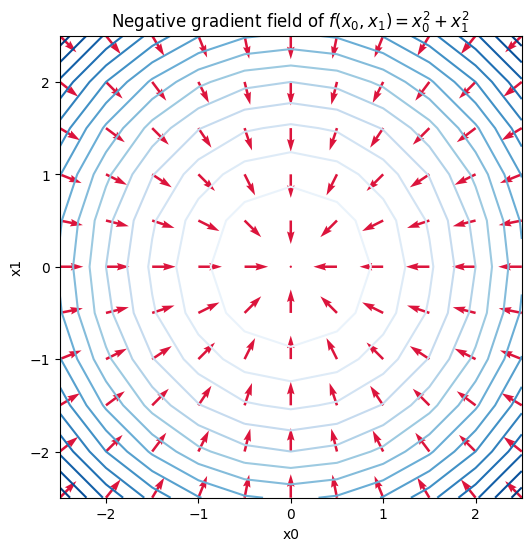

In [7]:
x0 = np.arange(-2.5, 2.6, 0.5)
x1 = np.arange(-2.5, 2.6, 0.5)
X0, X1 = np.meshgrid(x0, x1)
Z = X0**2 + X1**2
U = np.zeros_like(X0, dtype=float)
V = np.zeros_like(X1, dtype=float)

for i in range(X0.shape[0]):
    for j in range(X0.shape[1]):
        grad = numerical_gradient(function_2, np.array([X0[i, j], X1[i, j]], dtype=float))
        norm = np.linalg.norm(grad)
        if norm != 0:
            U[i, j] = -grad[0] / norm
            V[i, j] = -grad[1] / norm

fig, ax = plt.subplots(figsize=(6, 6))
ax.contour(X0, X1, Z, levels=15, cmap="Blues")
ax.quiver(X0, X1, U, V, color="crimson")
ax.set_title("Negative gradient field of $f(x_0, x_1) = x_0^2 + x_1^2$")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_aspect("equal")
plt.show()


### 경사하강법(Gradient Descent)

경사하강법은 현재 위치에서 기울기를 구하고, 그 반대 방향으로 조금 이동하는 과정을 반복해 함수의 최소값을 찾는 방법입니다.

$$
x_{t+1} = x_t - \eta \nabla f(x_t)
$$

여기서 $`\eta`$는 학습률(learning rate)입니다. 학습률이 너무 크면 최소값을 지나쳐 흔들릴 수 있고, 너무 작으면 매우 천천히 이동합니다. 손실함수에 대해 이 과정을 적용하면, 각 파라미터는 손실이 줄어드는 방향으로 조금씩 조정되고 이것이 곧 학습이 됩니다.


initial point: [-3.  4.]
final point: [-0.03458765  0.04611686]
initial loss: 25.0
final loss: 0.003323069989452288


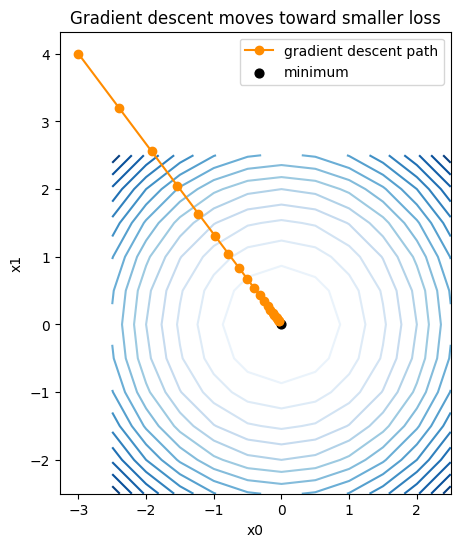

In [8]:
def gradient_descent(f, init_x, lr=0.1, step_num=20):
    x = init_x.astype(float).copy()
    history = [x.copy()]

    for _ in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad
        history.append(x.copy())

    return x, np.array(history)


init_x = np.array([-3.0, 4.0])
final_x, history = gradient_descent(function_2, init_x=init_x, lr=0.1, step_num=20)

print("initial point:", init_x)
print("final point:", final_x)
print("initial loss:", function_2(init_x))
print("final loss:", function_2(final_x))

fig, ax = plt.subplots(figsize=(6, 6))
ax.contour(X0, X1, Z, levels=15, cmap="Blues")
ax.plot(history[:, 0], history[:, 1], "o-", color="darkorange", label="gradient descent path")
ax.scatter(0, 0, color="black", s=40, label="minimum")
ax.set_title("Gradient descent moves toward smaller loss")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.legend()
ax.set_aspect("equal")
plt.show()

### 기울기와 학습의 연결

지금 예제에서는 단순한 2변수 함수 `f(x_0, x_1)`의 최소값을 찾았지만, 신경망 학습도 원리는 같습니다. 차이점은 `x_0`, `x_1` 대신 수많은 가중치와 편향이 있고, `f` 대신 손실함수 `L(W, b)`가 있다는 점입니다.

1. 현재 가중치로 예측을 만든다.
2. 손실함수로 오차를 계산한다.
3. 기울기 $`\nabla L`$를 구한다.
4. $`-\nabla L`$ 방향으로 가중치를 조금 이동시킨다.

이 과정을 반복하면 손실이 작은 지점으로 점점 이동하고, 모델의 예측도 함께 좋아집니다. 실제 딥러닝에서는 수치 미분 대신 역전파(backpropagation)로 기울기를 훨씬 빠르게 계산하지만, 학습이 "기울기를 따라 손실을 줄여 가는 과정"이라는 본질은 동일합니다.


## 미니 배치 학습 구현


In [9]:
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from neural_net.two_layer_net.two_layer_net import TwoLayerNet
from dataset.mnist import load_mnist

data = load_mnist(
    normalize=True,
    # flatten=True,
    one_hot_label=True,
)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)
print(network.params["W1"].shape)
print(network.params["b1"].shape)
print(network.params["W2"].shape)
print(network.params["b2"].shape)

print(f"before training accuracy: {network.accuracy(data[0][0], data[0][1])}")

(784, 50)
(50,)
(50, 10)
(10,)
before training accuracy: 0.10441666666666667


In [10]:
from time import perf_counter

# training
start = perf_counter()
network.train(
    data=data,
    epochs=10,
    batch_size=100,
    learning_rate=0.1,
)
elapsed = perf_counter() - start
print(f"train elapsed time: {elapsed:.2f}s")

epoch 1/10 - loss: 11.9839 - train acc: 0.7911 - test acc: 0.7958


KeyboardInterrupt: 